In [2]:
!pip install pandas
!pip install seaborn
!pip install matplotlib
!pip install -U scikit-learn

  Using cached numpy-2.4.6-cp311-cp311-macosx_14_0_arm64.whl.metadata (6.6 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 19.4 MB/s  0:00:00ta 0:00:02m
Using cached numpy-2.4.6-cp311-cp311-macosx_14_0_arm64.whl (5.5 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [pandas]2m1/2 [pandas]
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached contourpy-1.3.3-cp311-cp311-macosx_11_0_arm64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.63.0-cp311-cp311-macosx_10_9_universal2.whl.metadata (118 kB)
  Using cached kiwisolver-1.5.0-cp311-cp311-macosx_11_0_arm64.whl.metadata (5.1 kB)
  Using cached pillow-12.3.0-cp311-cp311-macosx_11_0_arm64.whl.metadata (9.1 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 76.5 MB/s  0:00:00
Using cached contourpy-1.3.3-cp311-

In [3]:
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

pd.set_option("display.max_columns", 100)
sns.set_style("whitegrid")

# Data Loading

[Ref] https://en.wikipedia.org/wiki/Iris_flower_data_set

In [4]:
_data = load_iris()
_data.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [5]:
data = _data.data
feature_names = _data.feature_names

df = pd.DataFrame(data, columns=feature_names)
df["target"] = _data.target

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


# Preprocessing

In [6]:
df.shape

(150, 5)

In [7]:
# 결측치 확인
df.isnull().sum()

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
dtype: int64

In [8]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [9]:
# target 코드(0,1,2)를 품종명으로 변환
target_mapping = {0: "Iris-setosa", 1: "Iris-versicolor", 2: "Iris-virginica"}
df["target"] = df["target"].map(target_mapping)

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [10]:
# 클래스 균형 확인 (품종별 표본 수)
df["target"].value_counts()

target
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

In [11]:
# 이후 분석에서 반복 사용할 특성(feature) 목록
features = feature_names
features

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

# EDA

## 품종별 중심·산포 비교

In [12]:
df.groupby("target").describe().T

target                   Iris-setosa  Iris-versicolor  Iris-virginica
sepal length (cm) count    50.000000        50.000000       50.000000
                  mean      5.006000         5.936000        6.588000
                  std       0.352490         0.516171        0.635880
                  min       4.300000         4.900000        4.900000
                  25%       4.800000         5.600000        6.225000
                  50%       5.000000         5.900000        6.500000
                  75%       5.200000         6.300000        6.900000
                  max       5.800000         7.000000        7.900000
sepal width (cm)  count    50.000000        50.000000       50.000000
                  mean      3.428000         2.770000        2.974000
                  std       0.379064         0.313798        0.322497
                  min       2.300000         2.000000        2.200000
                  25%       3.200000         2.525000        2.800000
                  50%       3.400000         2.800000        3.000000
                  75%       3.675000         3.000000        3.175000
                  max       4.400000         3.400000        3.800000
petal length (cm) count    50.000000        50.000000       50.000000
                  mean      1.462000         4.260000        5.552000
                  std       0.173664         0.469911        0.551895
                  min       1.000000         3.000000        4.500000
                  25%       1.400000         4.000000        5.100000
                  50%       1.500000         4.350000        5.550000
                  75%       1.575000         4.600000        5.875000
                  max       1.900000         5.100000        6.900000
petal width (cm)  count    50.000000        50.000000       50.000000
                  mean      0.246000         1.326000        2.026000
                  std       0.105386         0.197753        0.274650
                  min       0.100000         1.000000        1.400000
                  25%       0.200000         1.200000        1.800000
                  50%       0.200000         1.300000        2.000000
                  75%       0.300000         1.500000        2.300000
                  max       0.600000         1.800000        2.500000

**해석**
- 품종을 구분하는 1차 정보는 분포 모양이 아니라 **평균의 위치**에 있다.
- 특히 `petal length` 평균은 setosa 1.46 → versicolor 4.26 → virginica 5.55 로
  세 품종이 뚜렷하게 계단식으로 벌어진다. `petal width`도 유사하다.
- 반면 `sepal width`는 품종 간 평균 차이가 작아 구분에 덜 유용하다.

## 변수 간 차이 

In [13]:
# 품종 색상 팔레트 (setosa / versicolor / virginica)
custom_palette = ["#FF6B6B", "#2E8B57", "#45B7D1"]

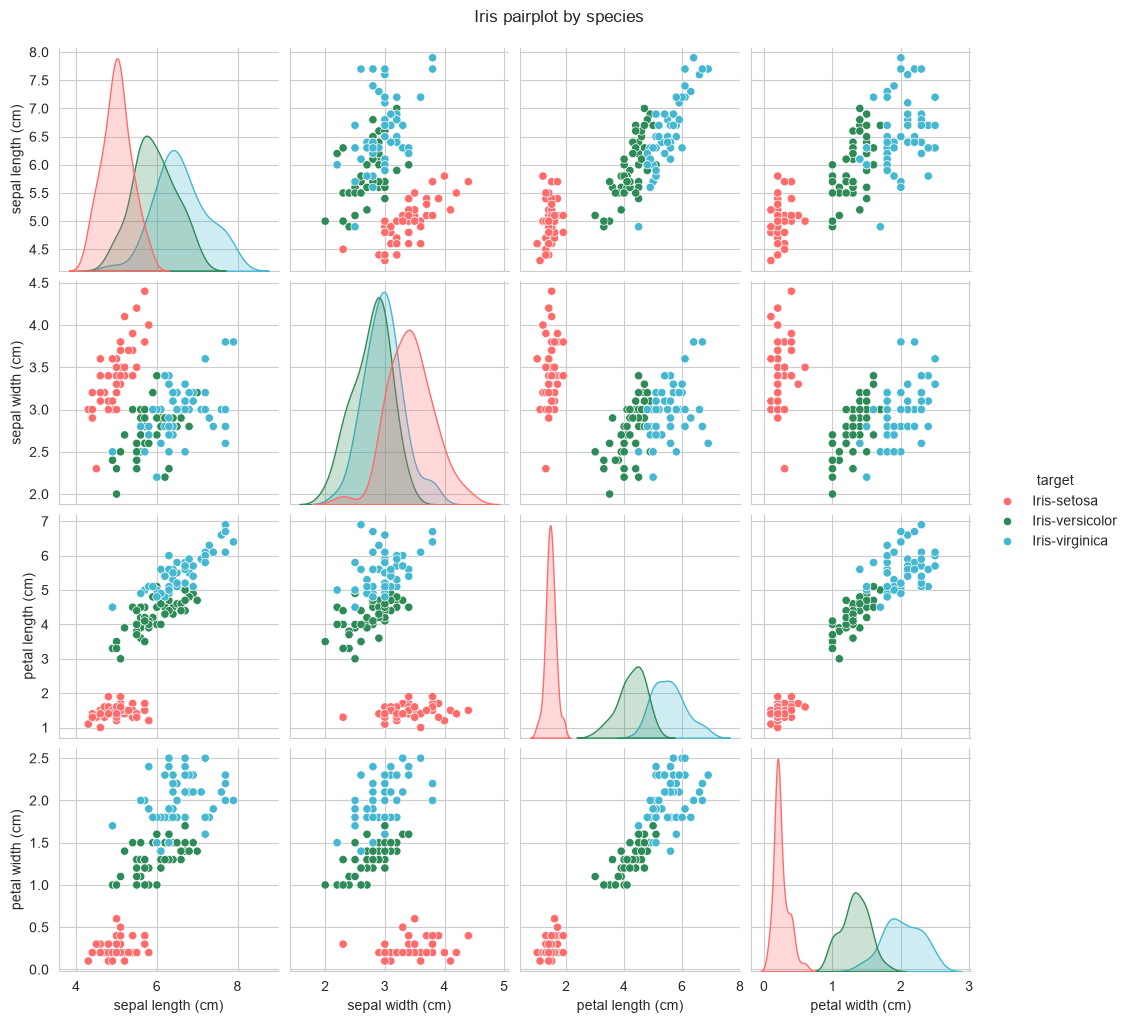

In [14]:
g = sns.pairplot(df, hue="target", palette=custom_palette, diag_kind="kde")
g.fig.suptitle("Iris pairplot by species", y=1.02)
plt.show()

**해석**
- **setosa(빨강)**는 어떤 변수 조합에서도 나머지 두 품종과 **완전히 분리**된다 (선형 분리 가능).
- versicolor(초록)와 virginica(파랑)는 일부 겹치지만, `petal length` × `petal width`
  조합에서 가장 깔끔하게 나뉜다 → **petal 계열 두 변수가 핵심 구분 변수**.
- `sepal width` 축은 세 품종이 크게 겹쳐, 단독으로는 구분력이 약하다.

## 변수별 분포 

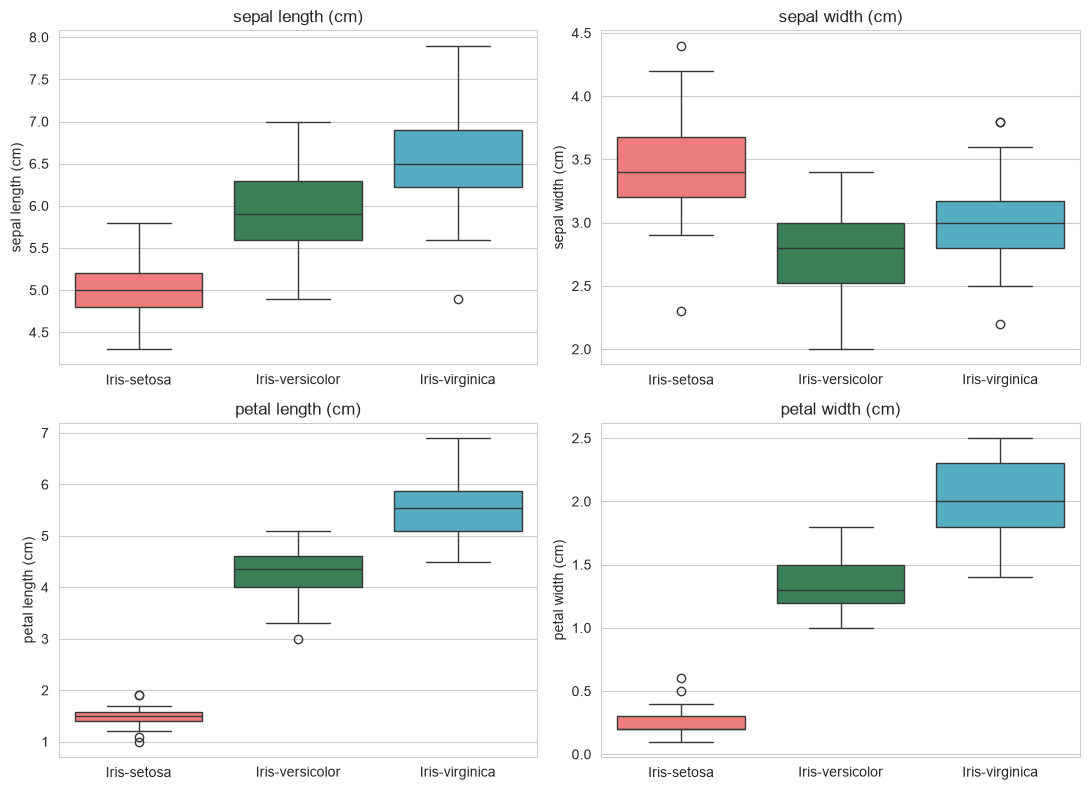

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for ax, col in zip(axes.ravel(), features):
    sns.boxplot(data=df, x="target", y=col, hue="target",
                palette=custom_palette, legend=False, ax=ax)
    ax.set_title(col)
    ax.set_xlabel("")
plt.tight_layout()
plt.show()

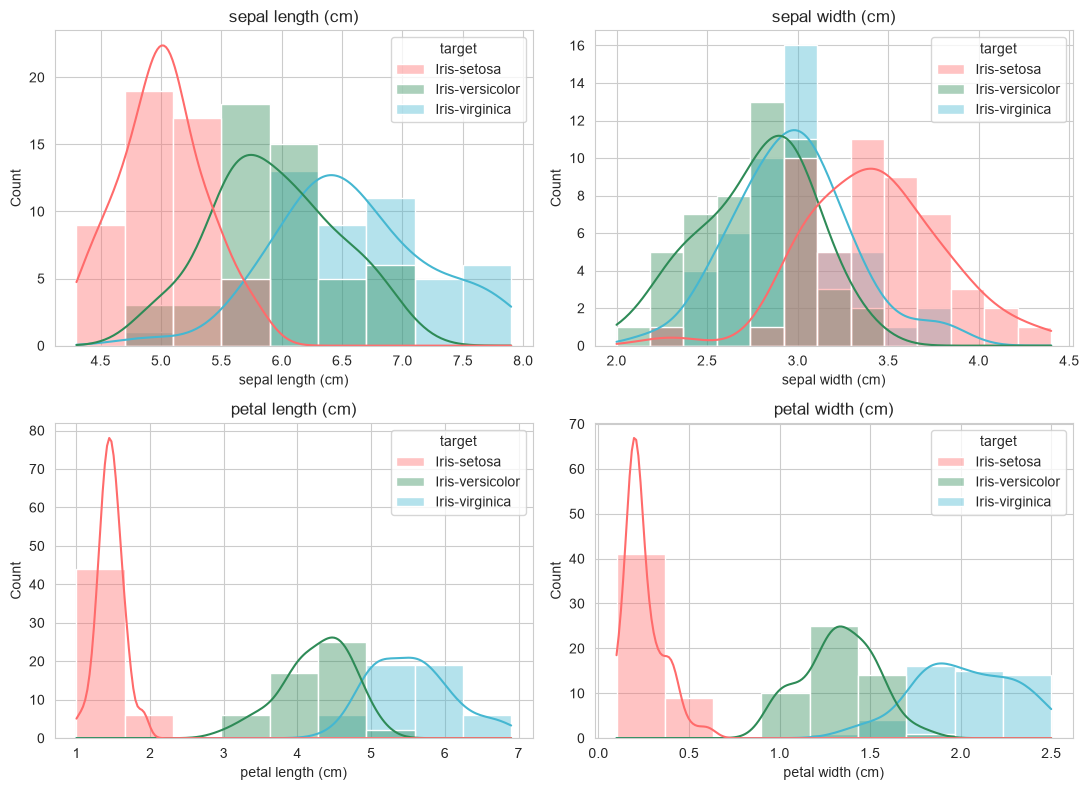

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for ax, col in zip(axes.ravel(), features):
    sns.histplot(data=df, x=col, hue="target", palette=custom_palette,
                 kde=True, alpha=0.4, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

**해석**
- `petal length`, `petal width`: 품종별 상자(box)와 분포가 **거의 겹치지 않음** → 구분력 높음.
- `sepal length`: 어느 정도 나뉘지만 인접 품종 간 겹침 존재.
- `sepal width`: 세 품종의 분포가 **크게 겹침** → 단독 구분력이 가장 약함.

## 분포 모양 

- 주의: 두 지표는 표본이 작으면 추정이 불안정함. 
- 지금은 **그룹당 n=50**에 불과하므로, 그룹 간 미세한 값 차이를 과해석하지 않아야 함.

In [17]:
df.groupby("target")[features].skew()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
target,,,,
Iris-setosa,0.120087,0.041167,0.106394,1.253861
Iris-versicolor,0.105378,-0.362845,-0.606508,-0.031180
Iris-virginica,0.118015,0.365949,0.549445,-0.129477


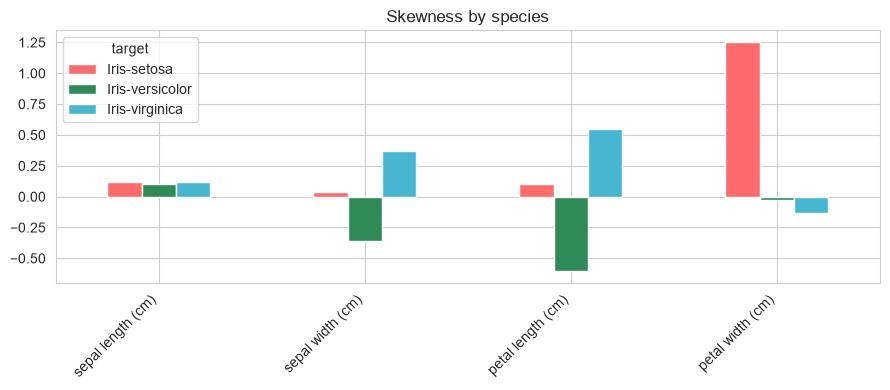

In [18]:
ax = df.groupby("target")[features].skew().T.plot(
    kind="bar", grid=True, figsize=(9, 4), color=custom_palette)
ax.set_title("Skewness by species")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [19]:
df.groupby("target")[features].kurt()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
target,,,,
Iris-setosa,-0.252689,0.954703,1.021576,1.719130
Iris-versicolor,-0.533010,-0.366237,0.047903,-0.410059
Iris-virginica,0.032904,0.706071,-0.153779,-0.602264


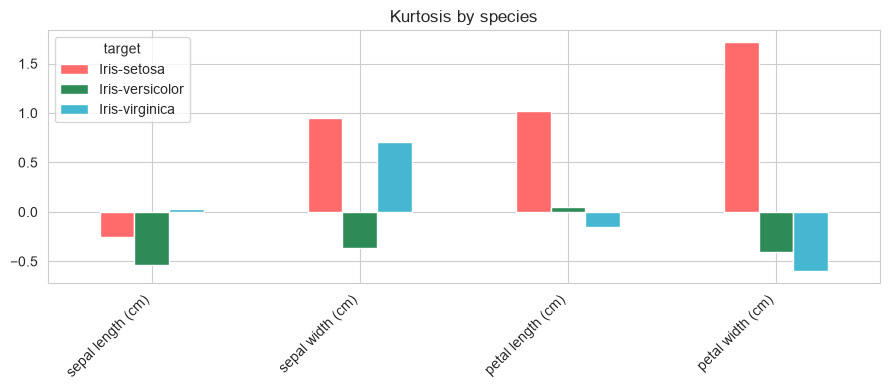

In [20]:
ax = df.groupby("target")[features].kurt().T.plot(
    kind="bar", grid=True, figsize=(9, 4), color=custom_palette)
ax.set_title("Kurtosis by species")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

**해석**
- 대부분의 왜도·첨도 값이 **0 근처**로, 품종 내 분포는 대체로 대칭적이고 정규분포에 가깝다
  → 평균·표준편차를 요약값으로 사용하는 데 큰 무리 없음 
- 예외적으로 **setosa의 `petal width` 왜도(≈1.25)** 가 높다 — 이 변수만 한쪽으로 쏠려 있음 

# Summary of EDA

- **품종 구분의 핵심은 분포 모양이 아니라 '변수의 위치(평균)'** 다.
- **petal length / petal width** 가 품종을 가르는 가장 강력한 변수다
  (pairplot·boxplot에서 품종 간 겹침이 거의 없음).
- **setosa** 는 나머지 두 품종과 완전히 분리되며, versicolor·virginica 구분에는 petal 계열이 결정적이다.
- **sepal width** 는 세 품종의 분포가 크게 겹쳐 단독 분리력이 가장 약하다.
- **skewness·kurtosis** 는 품종 내 분포가 대체로 대칭임을 확인하였고, 그 자체가 품종 구분 인사이트를 주지는 않는다.

----
End of Documents